**Table of contents**
1. [Set up and config](#1)
2. [Xử lý dữ liệu và EDA](#2)
3. [Mô hình và huấn luyện mô hình](#3)
4. [Đánh giá mô hình](#4)

# 1. Set up and config <a id='1'></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from abc import ABC, abstractmethod
from dataclasses import dataclass
import scipy
import sklearn
import random

In [2]:
from preprocessing import prepare_classification_data
from eda import (
  summarize_dataset,
  summarize_numeric_statistics,
  plot_class_distribution,
  plot_correlation_heatmap,
  plot_top_feature_distributions,
  )
from utils import learning_curve, loss_curve
from eval import (
  mcnemar_paired,
  reliability_diagram_multiclass
)
from models import (
  LogisticRegression as LR,
  SoftmaxRegression as SR,
  ProbitRegression as PR,
  LDA,
  QDA,
  GaussianNaiveBayes as GNB,
  KernelLogisticRegression as KLR
)

## Configuaration

In [3]:
# reproducibility
SEED = 42

# hyperparameters
LEARNING_RATE = .01
MAX_ITER = 10_000
REG = 1e-6
EPS = 1e-6
EPOCHS = 100
BATCH_SIZE = 100

# statistical significance level
ALPHA = .05

# data path
DATA_PATH = '../../data/raw/dry-bean-dataset/Dry_Bean_Dataset.xlsx'

In [4]:
def set_seed(seed: int) -> None:
  random.seed(seed)
  np.random.default_rng(seed)

set_seed(SEED)

# 2. Xử lý dữ liệu và EDA <a id='2'></a>
- Không validation:
$\text{Train} : \text{Test} = 80\% : 20\%$
- Có validation:
$\text{Train} : \text{Val} : \text{Test} = 70\% : 10\% : 20\%$

## 2.1 Xử lý dữ liệu

In [5]:
prepared = prepare_classification_data(
  file_path=DATA_PATH,
  target_col='Class',
  test_size=0.2,
  val_size=0.1,
  random_state=SEED,
)

df = prepared.df
X = prepared.X
y = prepared.y

X_train = prepared.X_train
X_val = prepared.X_val
X_test = prepared.X_test

X_train_scaled = prepared.X_train_scaled
X_val_scaled = prepared.X_val_scaled
X_test_scaled = prepared.X_test_scaled

y_train = prepared.y_train
y_val = prepared.y_val
y_test = prepared.y_test

target_le = prepared.target_encoder

# Keep train+val aliases for later experiments when needed.
X_train_val = np.vstack([X_train_scaled, X_val_scaled])
y_train_val = np.concatenate([y_train, y_val])

Loaded ../../data/raw/dry-bean-dataset/Dry_Bean_Dataset.xlsx -> shape (13611, 17)
Split sizes -> train: 9527, val: 1361, test: 2723


In [6]:
print(f"X_train_scaled.shape: {X_train_scaled.shape}")
print(f"y_train.shape: {y_train.shape}")
print(f"X_test_scaled.shape: {X_test_scaled.shape}")
print(f"y_test.shape: {y_test.shape}")

X_train_scaled.shape: (9527, 16)
y_train.shape: (9527,)
X_test_scaled.shape: (2723, 16)
y_test.shape: (2723,)


In [7]:
print(f"X_train_val.shape: {X_train_val.shape}")
print(f"y_train_val.shape: {y_train_val.shape}")
print(f"X_val.shape: {X_val.shape}")
print(f"y_val.shape: {y_val.shape}")

X_train_val.shape: (10888, 16)
y_train_val.shape: (10888,)
X_val.shape: (1361, 16)
y_val.shape: (1361,)


In [8]:
C = np.unique(y_train).shape[0]
print(f"Target classes identified: {target_le.classes_}")
print(f"Number of classes (C): {C}")

Target classes identified: ['BARBUNYA' 'BOMBAY' 'CALI' 'DERMASON' 'HOROZ' 'SEKER' 'SIRA']
Number of classes (C): 7


## 2.2 EDA

In [9]:
missing_summary = summarize_dataset(df, target_col='Class')

Shape: (13611, 17)

Dtypes:
Area                 int64
Perimeter          float64
MajorAxisLength    float64
MinorAxisLength    float64
AspectRation       float64
Eccentricity       float64
ConvexArea           int64
EquivDiameter      float64
Extent             float64
Solidity           float64
roundness          float64
Compactness        float64
ShapeFactor1       float64
ShapeFactor2       float64
ShapeFactor3       float64
ShapeFactor4       float64
Class                  str
dtype: object

Missing values: none

Class distribution:
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


In [10]:
feature_stats = summarize_numeric_statistics(X_train)

print('Descriptive statistics for numeric training features:')
feature_stats

Descriptive statistics for numeric training features:


,count,mean,std,min,q1,median,q3,max,iqr,missing_count,missing_rate
ConvexArea,9527.0,53811.5595,29911.7025,20684.0000,36683.5000,45244.0000,62433.5000,251082.0000,25750.0000,0,0.0
Area,9527.0,53090.9794,29464.6579,20420.0000,36299.5000,44710.0000,61458.5000,248424.0000,25159.0000,0,0.0
Perimeter,9527.0,855.4060,214.7239,524.7360,703.3640,795.3500,977.1465,1895.9400,273.7825,0,0.0
MajorAxisLength,9527.0,320.1449,85.8462,183.6012,253.2807,297.1470,376.0820,726.3735,122.8013,0,0.0
EquivDiameter,9527.0,253.1285,59.3623,161.2438,214.9836,238.5928,279.7345,562.4084,64.7509,0,0.0
MinorAxisLength,9527.0,202.3719,45.1374,122.5127,175.8721,192.4798,217.0575,460.1985,41.1853,0,0.0
AspectRation,9527.0,1.5824,0.2462,1.0364,1.4321,1.5503,1.7054,2.4303,0.2732,0,0.0
ShapeFactor3,9527.0,0.6439,0.0989,0.4103,0.5819,0.6422,0.6960,0.9636,0.1141,0,0.0
Eccentricity,9527.0,0.7507,0.0919,0.2628,0.7158,0.7641,0.8100,0.9114,0.0942,0,0.0
Compactness,9527.0,0.8000,0.0617,0.6406,0.7628,0.8014,0.8343,0.9816,0.0715,0,0.0


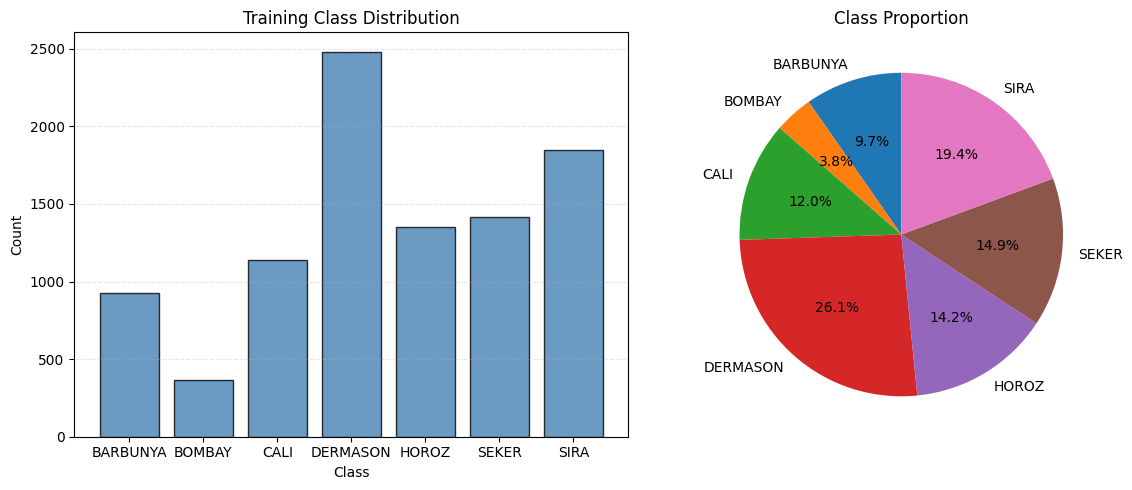

In [11]:
plot_class_distribution(
  y_train,
  class_names=target_le.classes_,
  title='Training Class Distribution',
)

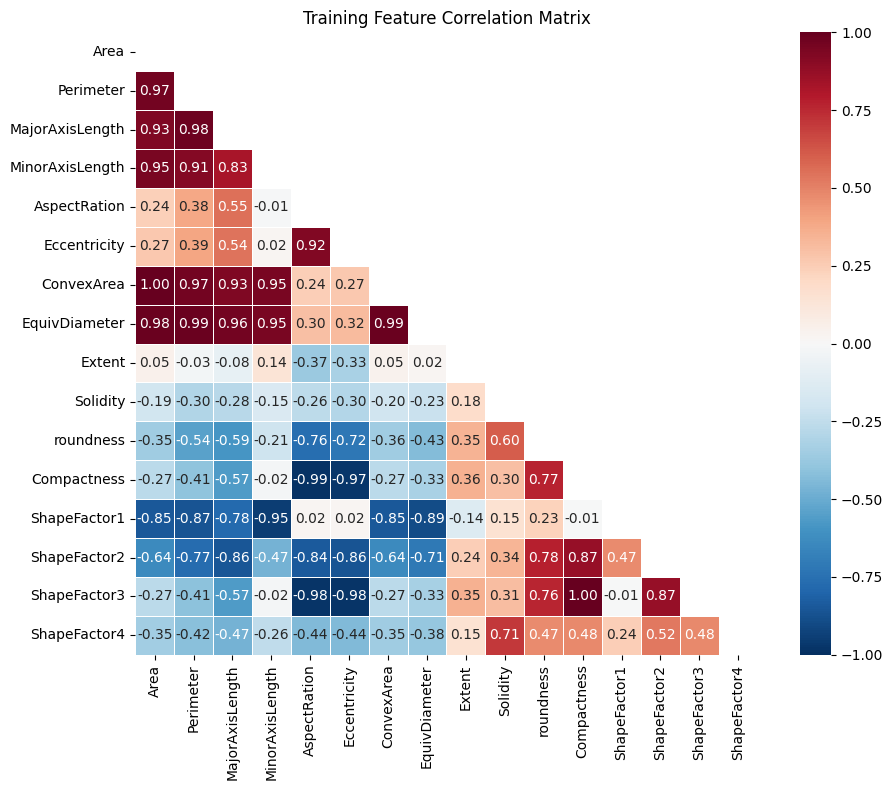

In [14]:
plot_correlation_heatmap(
  X_train,
  title='Training Feature Correlation Matrix',
)

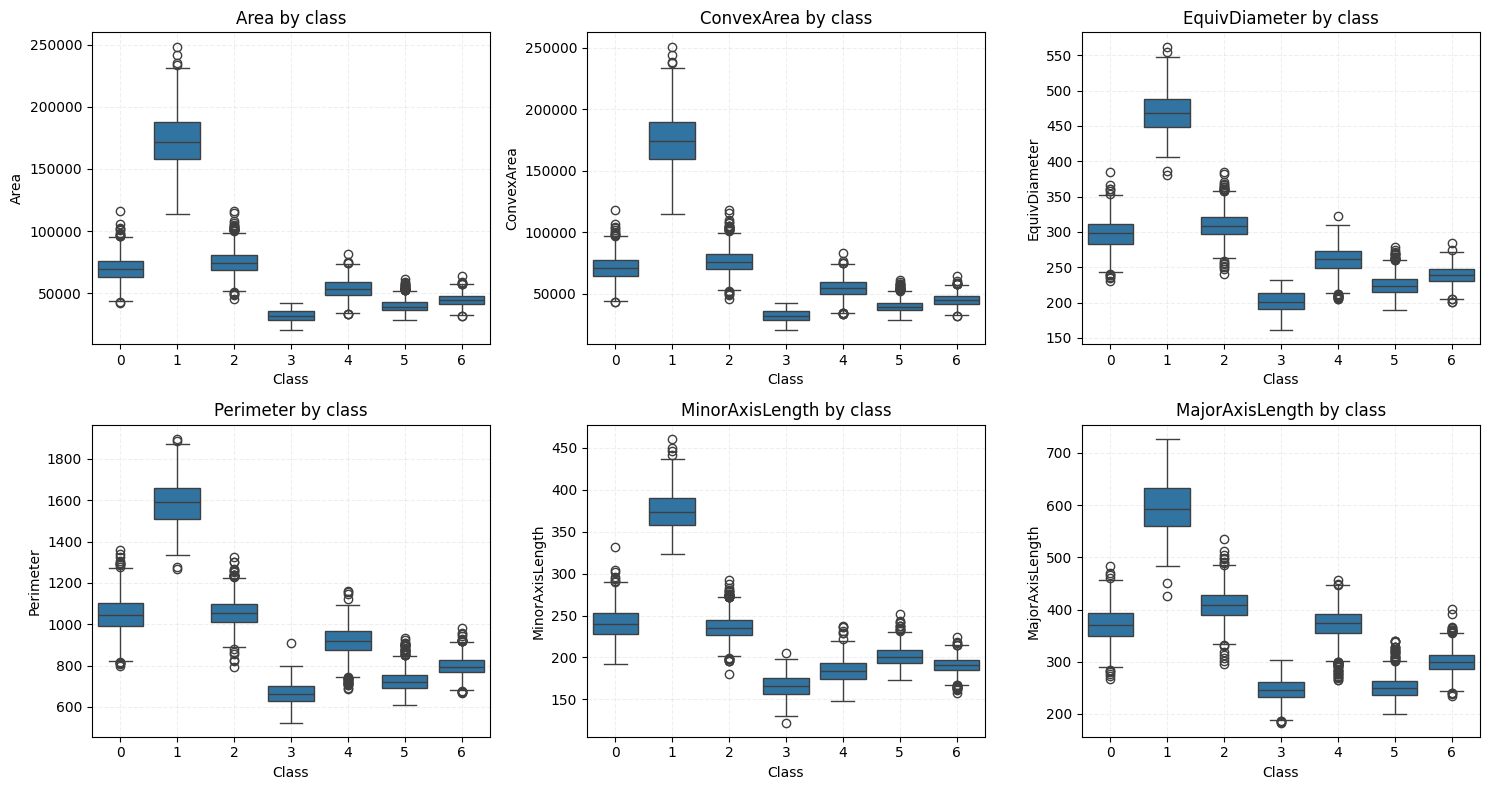

In [15]:
plot_top_feature_distributions(
  X_train,
  y_train,
  top_n=6,
)

# 3. Mô hình và huấn luyện mô hình <a id='3'></a>

In [ ]:
models = {}

### 3.0 Sanity check Logistic Regression với dữ liệu synthetic từ sklearn

In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X_syn, y_syn = make_classification(
  n_samples=3000,
  n_features=12,
  n_informative=8,
  n_redundant=2,
  n_classes=3,
  n_clusters_per_class=1,
  class_sep=1.2,
  random_state=SEED,
  weights=[0.35, 0.35, 0.30],
)

X_syn_train, X_syn_test, y_syn_train, y_syn_test = train_test_split(
  X_syn,
  y_syn,
  test_size=0.2,
  random_state=SEED,
  stratify=y_syn,
)

print(f'X_syn shape: {X_syn.shape}, y_syn shape: {y_syn.shape}')
print(f'X_syn_train shape: {X_syn_train.shape}, X_syn_test shape: {X_syn_test.shape}')
print('Class counts (full synthetic set):', np.bincount(y_syn))

X_syn shape: (3000, 12), y_syn shape: (3000,)
X_syn_train shape: (2400, 12), X_syn_test shape: (600, 12)
Class counts (full synthetic set): [1048 1052  900]


## 3.1 Logistic Regression (nhị phân và đa lớp)

### 3.1.1 Logistic Regression

In [ ]:
from models import LogisticRegression

logreg = LogisticRegression(reg=REG)
# logreg.fit(X=X_train_scaled, y=y_train, learning_rate=LEARNING_RATE, eps=EPS)
# models['Logistic Regression'] = logreg
# logreg_preds = logreg.predict(X=X_test_scaled)
# logreg_eval = logreg.evaluate(y_pred=logreg_preds, y_true=y_test)
# print("Logistic Regression Evaluation:", logreg_eval)


### 3.1.2 Các chiến thuật khi phân lớp đa lớp
- One-vs-Rest (OvR)
- One-vs-One (OvO)
- Softmax Regression (Multinomial Logistic Regression)

In [26]:
import importlib
import eval as eval_module

importlib.reload(eval_module)
from eval import classification_report as compact_classification_report

def evaluate_multiclass_strategy(y_true, y_pred, strategy_name: str) -> dict:
  metrics = compact_classification_report(
    y_pred=y_pred,
    y_true=y_true,
    average='weighted',
  )

  print(f"[{strategy_name}] Accuracy: {metrics['accuracy']:.4f}")
  print(
    f"precision={metrics['precision']:.4f}, "
    f"recall={metrics['recall']:.4f}, "
    f"f1-score={metrics['f1-score']:.4f}"
  )

  return {
    'strategy': strategy_name,
    'accuracy': metrics['accuracy'],
    'precision': metrics['precision'],
    'recall': metrics['recall'],
    'f1-score': metrics['f1-score'],
  }

In [27]:
def ovr_predict_with_logistic(X_train, y_train, X_test):
  classes = np.unique(y_train)
  models_ovr = {}
  class_scores = []

  for cls in classes:
    y_binary = (y_train == cls).astype(int)
    model = LR(learning_rate=LEARNING_RATE, eps=EPS, max_iter=MAX_ITER)
    model.fit(X_train, y_binary)
    models_ovr[cls] = model
    class_scores.append(model.predict_proba(X_test)[:, 1])

  class_scores = np.column_stack(class_scores)
  y_pred = classes[np.argmax(class_scores, axis=1)]
  return y_pred, models_ovr

ovr_preds, ovr_models = ovr_predict_with_logistic(
  X_train_scaled,
  y_train,
  X_test_scaled,
  )
ovr_metrics = evaluate_multiclass_strategy(y_test, ovr_preds, 'One-vs-Rest (OvR)')

Iteration 0: Loss 0.6931
Iteration 500: Loss 0.3029
Iteration 1000: Loss 0.2200
Iteration 1500: Loss 0.1846
Iteration 2000: Loss 0.1644
Iteration 2500: Loss 0.1511
Iteration 3000: Loss 0.1416
Iteration 3500: Loss 0.1343
Iteration 4000: Loss 0.1286
Iteration 4500: Loss 0.1239
Iteration 5000: Loss 0.1199
Iteration 5500: Loss 0.1165
Iteration 6000: Loss 0.1136
Iteration 6500: Loss 0.1110
Iteration 7000: Loss 0.1087
Iteration 7500: Loss 0.1066
Iteration 8000: Loss 0.1047
Iteration 8500: Loss 0.1029
Iteration 9000: Loss 0.1013
Iteration 9500: Loss 0.0999
Stopped at iteration 10000: reached max_iter=10000 before convergence.
Iteration 0: Loss 0.6931
Iteration 500: Loss 0.2084
Iteration 1000: Loss 0.1179
Iteration 1500: Loss 0.0822
Iteration 2000: Loss 0.0633
Iteration 2500: Loss 0.0517
Iteration 3000: Loss 0.0438
Iteration 3500: Loss 0.0380
Iteration 4000: Loss 0.0337
Iteration 4500: Loss 0.0303
Iteration 5000: Loss 0.0275
Iteration 5500: Loss 0.0253
Iteration 6000: Loss 0.0234
Iteration 650

In [24]:
from itertools import combinations

def ovo_predict_with_logistic(X_train, y_train, X_test):
  classes = np.unique(y_train)
  class_to_idx = {cls: idx for idx, cls in enumerate(classes)}

  votes = np.zeros((X_test.shape[0], len(classes)), dtype=int)
  confidences = np.zeros((X_test.shape[0], len(classes)), dtype=float)
  models_ovo = {}

  for cls_i, cls_j in combinations(classes, 2):
    pair_mask = (y_train == cls_i) | (y_train == cls_j)
    X_pair = X_train[pair_mask]
    y_pair = y_train[pair_mask]

    y_pair_binary = (y_pair == cls_j).astype(int)
    model = LR(learning_rate=LEARNING_RATE, eps=EPS, max_iter=MAX_ITER)
    model.fit(X_pair, y_pair_binary)
    models_ovo[(cls_i, cls_j)] = model

    pair_prob_j = model.predict_proba(X_test)[:, 1]
    pair_pred = np.where(pair_prob_j >= 0.5, cls_j, cls_i)

    idx_i, idx_j = class_to_idx[cls_i], class_to_idx[cls_j]
    votes[np.arange(X_test.shape[0]), [class_to_idx[p] for p in pair_pred]] += 1
    confidences[:, idx_i] += (1.0 - pair_prob_j)
    confidences[:, idx_j] += pair_prob_j

  max_votes = votes.max(axis=1, keepdims=True)
  is_tie = (votes == max_votes).sum(axis=1) > 1
  pred_idx = np.argmax(votes, axis=1)

  for i in np.where(is_tie)[0]:
    tie_mask = votes[i] == votes[i].max()
    tie_candidates = np.where(tie_mask)[0]
    best_tie_idx = tie_candidates[np.argmax(confidences[i, tie_candidates])]
    pred_idx[i] = best_tie_idx

  y_pred = classes[pred_idx]
  return y_pred, models_ovo

ovo_preds, ovo_models = ovo_predict_with_logistic(
  X_train_scaled,
  y_train,
  X_test_scaled,
  )
ovo_metrics = evaluate_multiclass_strategy(y_test, ovo_preds, 'One-vs-One (OvO)')

Iteration 0: Loss 0.6931
Iteration 500: Loss 0.1474
Iteration 1000: Loss 0.0915
Iteration 1500: Loss 0.0682
Iteration 2000: Loss 0.0551
Iteration 2500: Loss 0.0465
Iteration 3000: Loss 0.0405
Iteration 3500: Loss 0.0359
Iteration 4000: Loss 0.0324
Iteration 4500: Loss 0.0295
Iteration 5000: Loss 0.0271
Iteration 5500: Loss 0.0252
Iteration 6000: Loss 0.0235
Iteration 6500: Loss 0.0220
Iteration 7000: Loss 0.0207
Iteration 7500: Loss 0.0196
Iteration 8000: Loss 0.0186
Iteration 8500: Loss 0.0177
Iteration 9000: Loss 0.0169
Iteration 9500: Loss 0.0162
Stopped at iteration 10000: reached max_iter=10000 before convergence.
Iteration 0: Loss 0.6931
Iteration 500: Loss 0.2726
Iteration 1000: Loss 0.2082
Iteration 1500: Loss 0.1806
Iteration 2000: Loss 0.1649
Iteration 2500: Loss 0.1545
Iteration 3000: Loss 0.1472
Iteration 3500: Loss 0.1416
Iteration 4000: Loss 0.1373
Iteration 4500: Loss 0.1338
Iteration 5000: Loss 0.1309
Iteration 5500: Loss 0.1285
Iteration 6000: Loss 0.1265
Iteration 650

In [25]:
softmax_model = SR(learning_rate=LEARNING_RATE, eps=EPS, max_iter=MAX_ITER)
softmax_model.fit(X_train_scaled, y_train)

softmax_preds = softmax_model.predict(X_test_scaled)
softmax_metrics = evaluate_multiclass_strategy(
  y_test,
  softmax_preds,
  'Softmax Regression (Multinomial)',
  )

if 'models' not in globals():
  models = {}
models['Softmax Regression'] = softmax_model

Iteration 0: Loss 1.9459
Iteration 50: Loss 1.4534
Iteration 100: Loss 1.2207
Iteration 150: Loss 1.0848
Iteration 200: Loss 0.9937
Iteration 250: Loss 0.9267
Iteration 300: Loss 0.8740
Iteration 350: Loss 0.8308
Iteration 400: Loss 0.7943
Iteration 450: Loss 0.7627
Iteration 500: Loss 0.7349
Iteration 550: Loss 0.7102
Iteration 600: Loss 0.6880
Iteration 650: Loss 0.6679
Iteration 700: Loss 0.6496
Iteration 750: Loss 0.6328
Iteration 800: Loss 0.6173
Iteration 850: Loss 0.6029
Iteration 900: Loss 0.5897
Iteration 950: Loss 0.5773
Iteration 1000: Loss 0.5657
Iteration 1050: Loss 0.5549
Iteration 1100: Loss 0.5447
Iteration 1150: Loss 0.5352
Iteration 1200: Loss 0.5262
Iteration 1250: Loss 0.5177
Iteration 1300: Loss 0.5096
Iteration 1350: Loss 0.5020
Iteration 1400: Loss 0.4948
Iteration 1450: Loss 0.4880
Iteration 1500: Loss 0.4814
Iteration 1550: Loss 0.4752
Iteration 1600: Loss 0.4693
Iteration 1650: Loss 0.4636
Iteration 1700: Loss 0.4582
Iteration 1750: Loss 0.4530
Iteration 1800:

In [28]:
strategy_results_df = pd.DataFrame([
  ovr_metrics,
  ovo_metrics,
  softmax_metrics,
]).set_index('strategy')

print('Comparison of multiclass classification strategies:')
strategy_results_df.sort_values('accuracy', ascending=False)

Comparison of multiclass classification strategies:


,accuracy,precision,recall,f1-score
strategy,,,,
One-vs-One (OvO),0.918472,0.918742,0.918472,0.918372
Softmax Regression (Multinomial),0.915167,0.916044,0.915167,0.915315
One-vs-Rest (OvR),0.893867,0.893853,0.893867,0.893523


### 3.1.x Laplace Approximation (Bayesian Logistic Regression)

In [ ]:
from models import LogisticRegression

blr = LogisticRegression(learning_rate=LEARNING_RATE, eps=EPS)
blr.fit(X=X_train_scaled, y=y_train, solver='laplace_approximation')

models['Bayesian Logistic Regression (Laplace Approximation)'] = blr

blr_preds = blr.predict(X=X_test_scaled)
blr_eval = blr.evaluate(y_pred=blr_preds, y_true=y_test)
blr_acc = blr_eval['accuracy']
print(f'Bayesian Logistic Regression (Laplace Approximation) accuracy: {blr_acc:.2f}')

ValueError: LogisticRegression is binary-only; got 7 classes. Use SoftmaxRegression for multiclass problems.

In [ ]:
# 1) MAP parameters from the fitted Bayesian logistic regression
theta_map = blr.theta.copy()                    # [w1, w2, b]
X_aug = blr._augment(X_train_scaled)            # append bias column
y_binary = (y_train == blr.classes_[1]).astype(float)

# 2) Hessian of the negative log-posterior at MAP
#    H = X^T W X / N + lambda * I_prior
logits_map = X_aug @ theta_map
probs_map = 1.0 / (1.0 + np.exp(-np.clip(logits_map, -500, 500)))
W_diag = probs_map * (1.0 - probs_map)

n_samples = X_aug.shape[0]
prior_mask = blr._prior_mask(X_aug.shape[1])
reg = blr.prior_precision / n_samples

H_map = (X_aug.T * W_diag) @ X_aug / n_samples
H_map += reg * np.diag(prior_mask)
H_map += 1e-8 * np.eye(X_aug.shape[1])

print('theta_MAP =', theta_map)
print('Hessian at MAP =\n', H_map)

# 3) Laplace posterior: p(theta | D) ≈ N(theta_MAP, H_map^{-1})
posterior_cov = np.linalg.pinv(H_map)
posterior_cov = 0.5 * (posterior_cov + posterior_cov.T)
posterior_mean = theta_map

print('Posterior mean =', posterior_mean)
print('Posterior covariance =\n', posterior_cov)

# Optional sanity check: this should be numerically very close to blr.posterior_cov
if blr.posterior_cov is not None:
    print('max |posterior_cov - blr.posterior_cov| =', np.abs(posterior_cov - blr.posterior_cov).max())

# 4) Mean decision boundary for sigmoid probability = 0.5:
#    w1*x + w2*y + b = 0  =>  y(x) = -(b + w1*x) / w2
w1, w2, b = posterior_mean
if np.isclose(w2, 0.0):
    raise ValueError('w2 is too close to zero, so y(x) form of the boundary is unstable.')

x_grid = np.linspace(X_train_scaled[:, 0].min() - 0.5, X_train_scaled[:, 0].max() + 0.5, 400)
y_boundary_mean = -(b + w1 * x_grid) / w2

# 5) Delta method for boundary uncertainty.
#    For y(x; theta) = -(b + w1*x) / w2,
#    grad_theta y = [ -x/w2, (b + w1*x)/w2^2, -1/w2 ]
#    var[y(x)] ≈ grad^T Sigma grad
grads = np.column_stack([
    -x_grid / w2,
    (b + w1 * x_grid) / (w2 ** 2),
    -np.ones_like(x_grid) / w2,
])
boundary_var = np.einsum('bi,ij,bj->b', grads, posterior_cov, grads)
boundary_var = np.maximum(boundary_var, 0.0)
boundary_std = np.sqrt(boundary_var)

y_upper = y_boundary_mean + 2.0 * boundary_std
y_lower = y_boundary_mean - 2.0 * boundary_std

# 6) Plot training data, MAP boundary, and +-2 sigma uncertainty band
plt.figure(figsize=(8, 6))
plt.scatter(
    X_train_scaled[y_train == blr.classes_[0], 0],
    X_train_scaled[y_train == blr.classes_[0], 1],
    label=f'class {blr.classes_[0]}',
    alpha=0.7,
)
plt.scatter(
    X_train_scaled[y_train == blr.classes_[1], 0],
    X_train_scaled[y_train == blr.classes_[1], 1],
    label=f'class {blr.classes_[1]}',
    alpha=0.7,
)
plt.plot(x_grid, y_boundary_mean, color='black', linewidth=2, label='MAP decision boundary')
plt.fill_between(
    x_grid,
    y_lower,
    y_upper,
    color='tab:blue',
    alpha=0.2,
    label='Boundary uncertainty (±2σ)',
)
plt.xlim(x_grid.min(), x_grid.max())
plt.ylim(X_train_scaled[:, 1].min() - 0.5, X_train_scaled[:, 1].max() + 0.5)
plt.xlabel('x1 (scaled)')
plt.ylabel('x2 (scaled)')
plt.title('Laplace Approximation: MAP Boundary and ±2σ Uncertainty Band')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Optional alternative: sample several boundaries from N(theta_MAP, posterior_cov)
# to visualize posterior spread directly.
# sampled_thetas = np.random.multivariate_normal(posterior_mean, posterior_cov, size=100)
# plt.figure(figsize=(8, 6))
# plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, cmap='coolwarm', alpha=0.6)
# for theta_s in sampled_thetas:
#     ws1, ws2, bs = theta_s
#     if np.abs(ws2) < 1e-8:
#         continue
#     ys = -(bs + ws1 * x_grid) / ws2
#     plt.plot(x_grid, ys, color='gray', alpha=0.08)
# plt.plot(x_grid, y_boundary_mean, color='black', linewidth=2)
# plt.title('Posterior Samples of Decision Boundaries')
# plt.show()


## 3.2 Linear Discriminant Analysis - LDA và QDA

### 3.2.1 LDA và QDA

#### LDA

In [ ]:
from models import LDA

lda = LDA(reg=REG)
lda.fit(X=X_train_scaled, y=y_train)

models['LDA'] = lda

lda_preds = lda.predict(X=X_test_scaled)

lda_eval = lda.evaluate(y_pred=lda_preds, y_true=y_test)
lda_acc = lda_eval['accuracy']
print(f'LDA accuracy: {lda_acc:.4f}')

LDA accuracy: 0.9104


#### QDA

In [ ]:
from models import QDA

qda = QDA(reg=REG)
qda.fit(X=X_train_scaled, y=y_train)

models['QDA'] = qda

qda_preds = qda.predict(X=X_test_scaled)
qda_eval = qda.evaluate(y_pred=qda_preds, y_true=y_test)
qda_acc = qda_eval['accuracy']
print(f'QDA accuracy: {qda_acc:.4f}')

QDA accuracy: 0.9155


### 3.2.2 Fisher ratio feature ranking

For each feature $x_j$, we treat the projection direction as selecting that single coordinate, so the Fisher criterion becomes

$$
J(w_j) = J_j = \frac{\sum_{c=1}^{C} n_c (\mu_{c,j} - \mu_j)^2}{\sum_{c=1}^{C} n_c \, \sigma_{c,j}^2}
$$

where $n_c$ is the number of training samples in class $c$, $\mu_{c,j}$ and $\sigma_{c,j}^2$ are the class-wise mean and variance of feature $j$, and $\mu_j$ is the global mean of feature $j$. A larger $J_j$ means the feature separates classes better relative to its within-class spread.

In [ ]:
# Fisher ratio for each feature (multiclass version)
# J_j = sum_c n_c (mu_cj - mu_j)^2 / sum_c n_c sigma_cj^2

feature_names = list(X_train.columns)

classes, counts = np.unique(y_train, return_counts=True)
overall_mean = X_train_scaled.mean(axis=0)
fisher_scores = []

for j in range(X_train_scaled.shape[1]):
  between_class = 0.0
  within_class = 0.0

  for cls, n_c in zip(classes, counts):
    x_c = X_train_scaled[y_train == cls, j]
    mu_c = x_c.mean()
    var_c = x_c.var(ddof=1)

    between_class += n_c * (mu_c - overall_mean[j]) ** 2
    within_class += n_c * var_c

  fisher_scores.append(between_class / (within_class + 1e-12))

fisher_df = pd.DataFrame({
  'feature': feature_names,
  'fisher_ratio': fisher_scores,
}).sort_values('fisher_ratio', ascending=False).reset_index(drop=True)

print('Fisher ratio ranking (higher is better):')
fisher_df


Fisher ratio ranking (higher is better):


,feature,fisher_ratio
0,Area,12.553347
1,ConvexArea,12.530033
2,EquivDiameter,11.084359
3,Perimeter,10.629966
4,MinorAxisLength,9.701366
5,MajorAxisLength,9.472088
6,ShapeFactor2,5.381678
7,ShapeFactor1,5.307530
8,AspectRation,4.511665
9,Compactness,4.413558


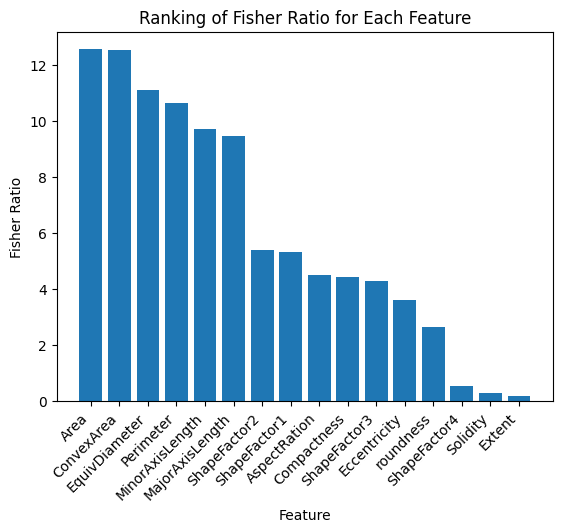

In [ ]:
plt.bar(fisher_df['feature'], fisher_df['fisher_ratio'])
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Fisher Ratio')
plt.title('Ranking of Fisher Ratio for Each Feature')

plt.show()

### 3.2.3 Vẽ quy chiếu LDA xuống 2D và biểu diễn đường quyết định

LDA 2D projection captures about 0.7539 of the discriminative eigenvalue mass.


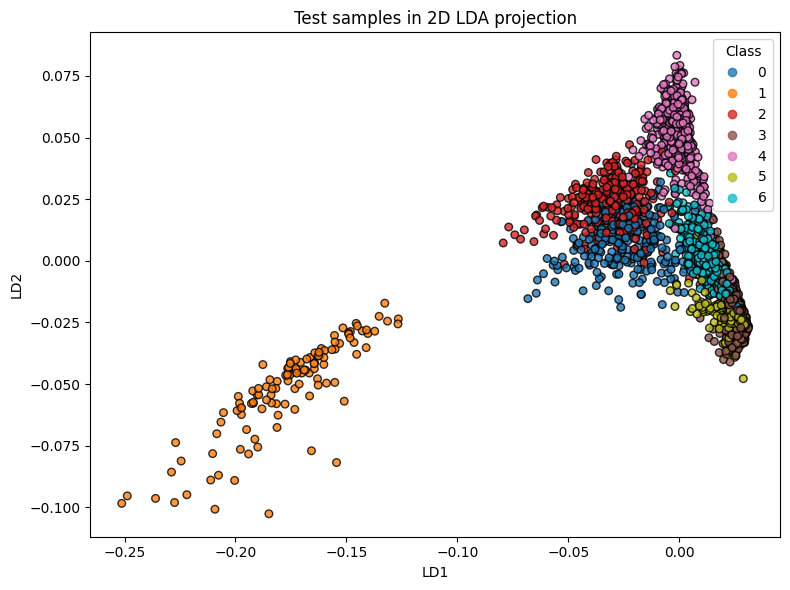

In [ ]:
# Project the data to 2D using the LDA model projection methods

lda_projection = LDA(reg=REG)
X_train_lda_2d = lda_projection.fit_transform(X_train_scaled, y_train, n_components=2)
X_test_lda_2d = lda_projection.transform(X_test_scaled, n_components=2)
explained_ratio = lda_projection.explained_discriminative_ratio(n_components=2)
print(f'LDA 2D projection captures about {explained_ratio.sum():.4f} of the discriminative eigenvalue mass.')

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
  X_test_lda_2d[:, 0],
  X_test_lda_2d[:, 1],
  c=y_test,
  cmap='tab10',
  alpha=0.8,
  edgecolor='k',
  s=30,
)
plt.title('Test samples in 2D LDA projection')
plt.xlabel('LD1')
plt.ylabel('LD2')
plt.legend(*scatter.legend_elements(), title='Class', loc='best')
plt.tight_layout()
plt.show()

LDA accuracy on 2D projected space: 0.7279


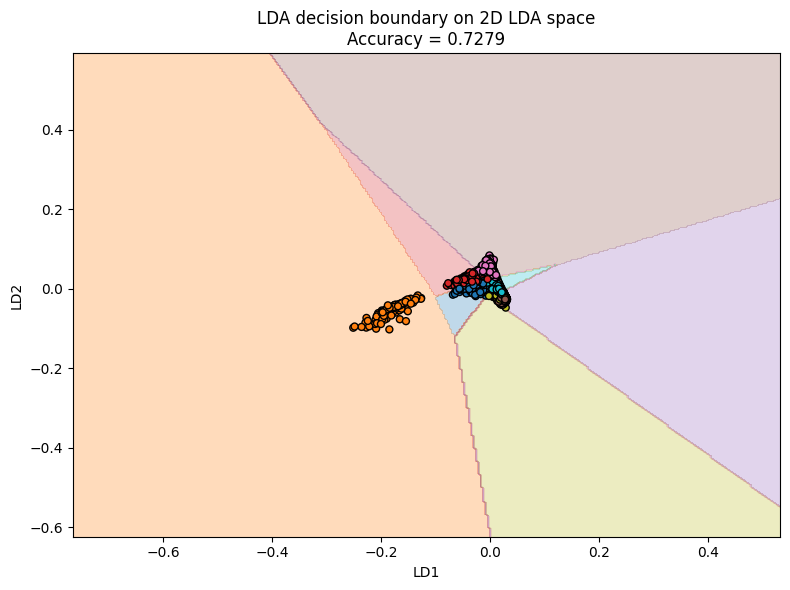

In [ ]:
# Fit LDA on the 2D projected space and draw its decision boundary

lda_2d = LDA(reg=REG)
lda_2d.fit(X_train_lda_2d, y_train)
lda_2d_preds_2d = lda_2d.predict(X_test_lda_2d)
lda_eval_2d = lda_2d.evaluate(lda_2d_preds_2d, y_test)
lda_acc_2d = lda_eval_2d['accuracy']
print(f'LDA accuracy on 2D projected space: {lda_acc_2d:.4f}')

all_points = np.vstack([X_train_lda_2d, X_test_lda_2d])
x_min, x_max = all_points[:, 0].min() - 0.5, all_points[:, 0].max() + 0.5
y_min, y_max = all_points[:, 1].min() - 0.5, all_points[:, 1].max() + 0.5
xx, yy = np.meshgrid(
  np.linspace(x_min, x_max, 300),
  np.linspace(y_min, y_max, 300),
)
grid = np.c_[xx.ravel(), yy.ravel()]
lda_grid = lda_2d.predict(grid).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, lda_grid, alpha=0.28, cmap='tab10')
plt.scatter(
  X_test_lda_2d[:, 0],
  X_test_lda_2d[:, 1],
  c=y_test,
  cmap='tab10',
  edgecolor='k',
  s=25,
)
plt.title(f'LDA decision boundary on 2D LDA space\nAccuracy = {lda_acc_2d:.4f}')
plt.xlabel('LD1')
plt.ylabel('LD2')
plt.tight_layout()
plt.show()

### 3.2.4 When LDA is better than QDA, and vice versa

**When LDA is usually better**

- LDA assumes all classes share one covariance matrix, so it estimates far fewer parameters than QDA. This usually makes LDA more stable when the dataset is not very large or the feature space is fairly high-dimensional.
- If the classes mainly differ in their means, while their spread and orientation are similar, the linear boundary from LDA is often sufficient and generalizes better.
- LDA is also less likely to overfit when some classes do not have many training samples.

**When QDA is usually better**

- QDA allows each class to have its own covariance matrix, so it is more appropriate when classes have clearly different spreads, shapes, or orientations.
- If the class boundary is nonlinear, QDA can model it better because its decision surface is quadratic.
- When each class has enough data to estimate its covariance reliably, QDA can exploit that extra flexibility and outperform LDA.

**How to read the plots in this notebook**

- The 2D LDA projection keeps the two most discriminative directions, so it gives the clearest visual view of class separation.
- If the LDA boundary already follows the visible class regions well, then the shared-covariance assumption is likely reasonable.
- If the QDA boundary fits the visible clusters better, especially in curved or uneven-density regions, then class-specific covariance is likely important and QDA is the better model.
- If QDA produces a more complicated boundary without a meaningful gain in accuracy, then its extra flexibility is probably unnecessary and LDA is the safer choice.



### 3.2.5 Gaussian Naive Bayes (giả thiết độc lập) với LDA

In [ ]:
from models import GaussianNaiveBayes

gnb = GaussianNaiveBayes(reg=REG)
gnb.fit(X=X_train_scaled, y=y_train)
gnb_preds = gnb.predict(X=X_test_scaled)
gnb_eval = gnb.evaluate(gnb_preds, y_test)
gnb_acc = gnb_eval['accuracy']
print(f'Gaussian Naive Bayes accuracy: {gnb_acc:.4f}')

Gaussian Naive Bayes accuracy: 0.9038


## 3.3 Perceptron và Logistic Regression có Regularization

## 3.4 Probit

In [ ]:
from models import ProbitRegression, KernelLogisticRegression

# 1. Khởi tạo và huấn luyện mô hình Probit
probit_model = ProbitRegression(learning_rate=0.01, max_iter=5000)
probit_model.fit(X_train_scaled, y_train)

models['Probit Regression'] = probit_model

# 2. Dự đoán trên tập Validation
y_val_pred_probit = probit_model.predict(X_val_scaled)

# 3. Đánh giá
accuracy_probit = np.mean(y_val_pred_probit == y_val)
print(f"Probit Regression Accuracy: {accuracy_probit:.4f}")

# 4. Xem báo cáo chi tiết (sử dụng method evaluate từ base class)
# probit_model.evaluate(y_val_pred_probit, y_val)


## 3.5 Perceptron và KernelLogisticRegression

In [ ]:
# Ví dụ sử dụng trên dữ liệu XOR để thấy ranh giới phi tuyến
X_xor = np.random.randn(200, 2)
y_xor = np.logical_xor(X_xor[:, 0] > 0, X_xor[:, 1] > 0).astype(int)

# Khởi tạo Kernel LR với RBF Kernel (hàm Gaussian)
kernel_model = KernelLogisticRegression(
    kernel='rbf', 
    gamma=0.5, 
    lam=1e-4, 
    learning_rate=0.05, 
    max_iter=2000
)

models['Kernel Logistic Regression (RBF)'] = kernel_model

# Huấn luyện
kernel_model.fit(X_xor, y_xor)

# Dự đoán và kiểm tra độ chính xác
y_pred_xor = kernel_model.predict(X_xor)
print(f"Kernel LR Accuracy (XOR): {np.mean(y_pred_xor == y_xor):.4f}")

# Đoạn code vẽ Decision Boundary
def plot_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='RdBu', edgecolors='k')
    plt.title(title)
    plt.show()

plot_boundary(kernel_model, X_xor, y_xor, "Kernel Logistic Regression (RBF)")


# 4. Đánh giá mô hình <a id='4'></a>

## 4.1 Đồ thị hàm mất mát theo số vòng lặp

## 4.2 Vẽ đường ranh giới quyết định trong không gian 2D

## 4.3 So sánh tất cả các mô hình trong một bảng kết quả thống nhất

## 4.4 k-fold cross-validation (k=5) và báo cáo $\text{mean} \pm \text{std}$ cho mỗi chỉ số

In [ ]:
from eval import kfold_cross_val_score

retrained_models = {
  "Softmax Regression": lambda: SR(learning_rate=LEARNING_RATE, eps=EPS, max_iter=MAX_ITER),
  "LDA": lambda: LDA(reg=REG),
  "QDA": lambda: QDA(reg=REG),
  "Gaussian Naive Bayes": lambda: GNB(reg=REG),
}

metric_order = ["accuracy", "precision", "recall", "f1-score"]
cv_rows = []

for model_name, builder in retrained_models.items():
  result = kfold_cross_val_score(
    model=builder(),
    X=X_train_scaled,
    y=y_train,
    k=5,
    average="weighted",
    random_state=SEED,
    shuffle=True,
    model_builder=builder,
  )

  row = {"Model": model_name}
  for metric in metric_order:
    row[metric] = result["summary"][metric]["mean_std"]
  cv_rows.append(row)

cv_df = pd.DataFrame(cv_rows).set_index("Model")
print("5-fold cross-validation results (mean +- std):")
cv_df

## 4.5 Vẽ **Precision-Recall curve** và so sánh Average Precision (AP) giữa các mô hình

In [ ]:
from eval import compare_average_precision

models_for_pr = {}
for name, model in models.items():
  if not hasattr(model, "predict_proba"):
    print(f"Skip {name}: no predict_proba")
    continue

  try:
    _ = model.predict_proba(X_test_scaled[:5])
    models_for_pr[name] = model
  except Exception as e:
    print(f"Skip {name}: {e}")

if len(models_for_pr) == 0:
  raise ValueError("No valid models found for precision-recall plotting.")

ap_scores = compare_average_precision(
  models=models_for_pr,
  X=X_test_scaled,
  y_true=y_test,
  title="Precision-Recall Curves and Average Precision"
)

print("\nAverage Precision by model:")
for name, score in sorted(ap_scores.items(), key=lambda x: x[1], reverse=True):
  print(f"{name}: {score:.4f}")

## 4.6 McNemar's test

In [ ]:
pairs = [
  ('GNB', 'LDA', gnb_preds, lda_preds),
  ('GNB', 'QDA', gnb_preds, qda_preds),
  ('LDA', 'QDA', lda_preds, qda_preds),
  ('LR', 'BLR', logreg_preds, blr_preds),
]

for pair in pairs:
  name1, name2, preds1, preds2 = pair
  p_value = mcnemar_paired(preds1, preds2, y_test)
  print(f'McNemar test between {name1} and {name2}: p-value = {p_value:.4f}')
  if p_value < ALPHA:
    print(f'--> The difference between {name1} and {name2} is statistically significant at alpha={ALPHA}')
  else:
    print(f'--> No statistically significant difference between {name1} and {name2} at alpha={ALPHA}')

NameError: name 'gnb_preds' is not defined

## 4.7 Phân tích Calibration của xác suất đầu ra bằng reliability diagram.

In [ ]:
# Models already fitted earlier in the notebook
models_for_calibration = {
    'LDA': lda,
    'QDA': qda,
    'GNB': gnb,
    'BLR': blr,
    # 'LR': lr,   # uncomment if this model has predict_proba(...)
}

n_bins = 10
fig, axes = plt.subplots(1, len(models_for_calibration), figsize=(5 * len(models_for_calibration), 4), sharey=True)

if len(models_for_calibration) == 1:
  axes = [axes]

calibration_summary = []

for ax, (model_name, model) in zip(axes, models_for_calibration.items()):
  y_prob = model.predict_proba(X_test_scaled)

  bin_centers, counts, conf_mean, acc_mean, ece = reliability_diagram_multiclass(
    y_true=y_test,
    probs=y_prob,
    class_labels=model.classes_,
    n_bins=n_bins,
  )

  valid = ~np.isnan(conf_mean) & ~np.isnan(acc_mean)

  ax.plot([0, 1], [0, 1], '--', color='gray', linewidth=1, label='Perfect calibration')
  ax.plot(conf_mean[valid], acc_mean[valid], marker='o', linewidth=2, label='Observed')
  ax.bar(
    bin_centers,
    np.nan_to_num(acc_mean, nan=0.0),
    width=1.0 / n_bins,
    alpha=0.25,
    edgecolor='black',
  )

  ax.set_ylim(0, 1)

  calibration_summary.append({
    'model': model_name,
    'ece': ece,
    'avg_confidence': float(np.nanmean(conf_mean)),
    'avg_accuracy': float(np.nanmean(acc_mean)),
  })

axes[0].set_ylabel('Empirical accuracy')
axes[0].legend(loc='lower right')
plt.suptitle('Calibration analysis with reliability diagrams', y=1.02)
plt.tight_layout()
plt.show()

calibration_summary = sorted(calibration_summary, key=lambda x: x['ece'])
print('Calibration summary (lower ECE is better):')
for row in calibration_summary:
  print(
    f"{row['model']}: "
    f"ECE={row['ece']:.4f}, "
    f"avg_confidence={row['avg_confidence']:.4f}, "
    f"avg_accuracy={row['avg_accuracy']:.4f}"
  )